
# Bengali Sentiment Analysis (Multinomial Naive Bayes) — Notebook
- Cleaning, tokenization, optional stemming (Bangla)
- Train/Val/Test split
- TF-IDF (word + char n-grams)
- Grid search on `alpha` and n-gram ranges
- External **stopwords** file
- Model export + quick inference


In [18]:

# (Optional) Install/upgrade dependencies here if needed.
# Remove '!' if you're running in an environment that doesn't allow shell commands.
# You can comment this cell out once everything is installed.
# %%capture  # uncomment to silence output
#!python -m pip install --upgrade pip setuptools wheel
#!pip install pandas numpy scipy scikit-learn joblib bangla-stemmer


In [19]:

# Imports
from __future__ import annotations
import os, re, json, math, textwrap
from pathlib import Path
from typing import List, Iterable, Set, Tuple

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from joblib import dump, load

import matplotlib.pyplot as plt

# Optional Bangla stemmer
try:
    from bangla_stemmer.stemmer import BanglaStemmer
    _BN_STEMMER = BanglaStemmer()
except Exception:
    _BN_STEMMER = None

# Global stopwords set (populated from file)
STOPWORDS: Set[str] = set()

print('Versions:')
import sys
print('Python:', sys.version.split()[0])
import sklearn, pandas, numpy, scipy
print('sklearn:', sklearn.__version__)
print('pandas:', pandas.__version__)
print('numpy:', numpy.__version__)
print('scipy:', scipy.__version__)


Versions:
Python: 3.11.9
sklearn: 1.7.1
pandas: 2.3.2
numpy: 2.3.2
scipy: 1.16.1


In [20]:
# # Directory containing the CSV files
# directory = r"C:\Users\DELL\Desktop\nlp_codes\eGov-Lens" # Replace with the actual directory path

# # List all CSV files in the directory
# csv_files = [f for f in os.listdir(directory) if f.endswith(".csv")]

# # Initialize an empty list to store DataFrames
# dataframes = []

# # Read each CSV file into a DataFrame and append to the list
# for file in csv_files:
#     filepath = os.path.join(directory, file)
#     try:
#         df = pd.read_csv(filepath)
#         dataframes.append(df)
#     except Exception as e:
#         print(f"Error reading {file}: {e}")

# # Concatenate all DataFrames into a single DataFrame
# if dataframes:
#     merged_df = pd.concat(dataframes, ignore_index=True)

#     # Display the merged DataFrame
#     display(merged_df)
# else:
#     print("No CSV files found or processed.")
    
# merged_df.to_csv("dataset.csv", index=False)
# print("Merged data saved to dataset.csv")

In [41]:

# ===========================
# Paths & Flags
# ===========================
DATA_PATH = Path('dataset.csv')              # <-- change to your CSV
STOPWORDS_PATH = Path('stopwords_bn.txt')    # <-- change to your stopwords file
ARTIFACT_DIR = Path('artifacts')
USE_STEM = False                             # toggle stemming (requires bangla-stemmer)
RANDOM_STATE = 42

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_PATH:', DATA_PATH.resolve())
print('STOPWORDS_PATH:', STOPWORDS_PATH.resolve())
print('ARTIFACT_DIR:', ARTIFACT_DIR.resolve())
print('USE_STEM:', USE_STEM)


DATA_PATH: C:\Users\DELL\Desktop\nlp_codes\dataset.csv
STOPWORDS_PATH: C:\Users\DELL\Desktop\nlp_codes\stopwords_bn.txt
ARTIFACT_DIR: C:\Users\DELL\Desktop\nlp_codes\artifacts
USE_STEM: False


In [42]:

# ===========================
# Text utilities for Bangla
# ===========================
BN_DIGITS = '০১২৩৪৫৬৭৮৯'
EN_DIGITS = '0123456789'

BN_PUNCT = '।॥‘’“”—–…•'
EXTRA_PUNCT = r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""
PUNCT_TABLE = str.maketrans({c: ' ' for c in BN_PUNCT + EXTRA_PUNCT})

URL_RE = re.compile(r'https?://\S+|www\.\S+', re.UNICODE)
MENTION_RE = re.compile(r'[@#][\w\-_]+', re.UNICODE)
MULTISPACE_RE = re.compile(r'\s+', re.UNICODE)

def bn_normalize(text: str) -> str:
    if not isinstance(text, str):
        return ''
    t = text.strip()
    t = URL_RE.sub(' ', t)
    t = MENTION_RE.sub(' ', t)
    t = t.translate(PUNCT_TABLE)
    for bd, ed in zip(BN_DIGITS, EN_DIGITS):
        t = t.replace(bd, ed)
    t = MULTISPACE_RE.sub(' ', t)
    return t.strip()

def load_stopwords(path: Path) -> Set[str]:
    if not path or not path.exists():
        print('[info] No external stopwords file found; proceeding without stopwords filtering.')
        return set()
    words = set()
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            words.add(line)
    print(f'[info] Loaded {len(words)} stopwords from {path}')
    return words

def bn_tokenize(text: str, remove_stopwords: bool = True, stem: bool = False) -> List[str]:
    t = bn_normalize(text)
    tokens = [tok for tok in t.split(' ') if tok]
    if remove_stopwords and STOPWORDS:
        tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 1]
    if stem and _BN_STEMMER is not None:
        tokens = [_BN_STEMMER.stem(w) for w in tokens]
    return tokens

class BengaliCleaner(BaseEstimator, TransformerMixin):
    def __init__(self): pass
    def fit(self, X: Iterable[str], y=None): return self
    def transform(self, X: Iterable[str]) -> List[str]:
        return [bn_normalize(x) for x in X]


In [43]:

# # ===========================
# # Pipeline builder
# # ===========================
# def build_pipeline(use_stem: bool = False) -> Pipeline:
#     word_vec = TfidfVectorizer(
#         tokenizer=lambda s: bn_tokenize(s, remove_stopwords=True, stem=use_stem),
#         preprocessor=lambda s: s,
#         token_pattern=None,     # required when using a custom tokenizer
#         lowercase=False,
#         ngram_range=(1, 2),
#         min_df=2
#     )
#     char_vec = TfidfVectorizer(
#         analyzer='char',
#         ngram_range=(3, 5),
#         min_df=2
#     )
#     features = FeatureUnion([('word', word_vec), ('char', char_vec)])
#     pipe = Pipeline([('clean', BengaliCleaner()), ('features', features), ('clf', MultinomialNB())])
#     return pipe

# ===========================
# Pipeline builder
# ===========================

# Create a pickle-safe tokenizer CLASS to replace the lambda function.
# This class takes the `use_stem` flag during initialization.
class BengaliTokenizer:
    def __init__(self, use_stem: bool = False):
        self.use_stem = use_stem
    
    def __call__(self, text: str) -> List[str]:
        # This calls your existing bn_tokenize function with the correct stem setting
        return bn_tokenize(text, remove_stopwords=True, stem=self.use_stem)


def build_pipeline(use_stem: bool = False) -> Pipeline:
    word_vec = TfidfVectorizer(
        tokenizer=BengaliTokenizer(use_stem=use_stem),  # <-- Use the new class
        preprocessor=None,                              # <-- Replace `lambda s: s` with None
        token_pattern=None,     # required when using a custom tokenizer
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2
    )
    char_vec = TfidfVectorizer(
        analyzer='char',
        ngram_range=(3, 5),
        min_df=2
    )
    features = FeatureUnion([('word', word_vec), ('char', char_vec)])
    pipe = Pipeline([('clean', BengaliCleaner()), ('features', features), ('clf', MultinomialNB())])
    return pipe


In [44]:

# ===========================
# Create sample files if your paths don't exist
# ===========================
from pathlib import Path

SAMPLE_ROWS = [
    ["কীটনাশকের গায়ে ১০০ লেখা থাকলে ৪০ টাকায় পাওয়া যায়", "neutral"],
    ["এলপিজির গায়ে মূল্য কেন দেওয়া হয় না, আজও বুঝতে পারি না", "negative"],
    ["সারের বস্তার গায়ে মূল্য লেখাটাও বাধ্যতামূলক করুন", "positive"],
    ["গায়ে লেখা দামে বেশির ভাগ পণ্য বিক্রি হয় না, বেশি দামে কিনতে হয়, এটা দেখার লোক নেই", "negative"],
    ["ঔষধের প্রত্যেকটি পাতায় মূল্য লেখা থাকলে প্রতারণা থেকে রক্ষা পাওয়া যাবে", "positive"],
    ["ভারতীয় পণ্য বর্জন করুন এবং পুরোপুরি কার্যকর করুন", "positive"],
    ["দেশের মানুষ কোটি কোটি টাকা চায় না, তারা চায় পেট ভরে দুবার খেতে, খাদ্যের দাম কমে গরীব ও মধ্যবিত্ত মানুষের দিকে তাকিয়ে", "positive"],
    ["সঠিক পদক্ষেপ নেওয়া হয়েছে", "positive"],
    ["অ-কর্মা মন্ত্রী, কাজ হবে না", "negative"],
    ["খালি বলে যাচ্ছে, বাজার নিয়ন্ত্রণ হচ্ছে না, গরিব মানুষ বাঁচতে চায়", "negative"],
    ["এই মেশিন কি ভাবে নেওয়া যাবে, সফিউল ভাইয়ের সাথে যোগাযোগ করার কোনো উপায় আছে কি?", "neutral"],
    ["সাত মাছ চাষের এই ডিভাইসটি কি বাংলাদেশে পাওয়া যাবে", "neutral"],
    ["এই ডিভাইসটি কি এখনো মার্কেটে আসে নাই, কোথায় পাওয়া যাবে জানালে উপকৃত হবো", "neutral"],
    ["কবে নাগাদ এই স্মার্ট টেকনোলজি পাব, আপনাকে অনেক ধন্যবাদ", "neutral"],
    ["এই ডিভাইস এখন কি মার্কেটে আছে, থাকলে কেউ জানান", "neutral"],
]

if not DATA_PATH.exists():
    print('[info] Writing sample dataset to', DATA_PATH)
    import pandas as _pd
    _pd.DataFrame(SAMPLE_ROWS, columns=['text','sentiment']).to_csv(DATA_PATH, index=False)

if not STOPWORDS_PATH.exists():
    print('[info] Writing sample stopwords to', STOPWORDS_PATH)
    stopwords_example = """# minimal example — add your own!
এবং
কিন্তু
যদি
তবে
কোনো
কিছু
এই
সেই
হয়
হবে
ছিল
না
তো
কি
কে
যে
বা
আর
তুমি
আমরা
আপনি
তারা
তাদের
"""
    with open(STOPWORDS_PATH, 'w', encoding='utf-8') as f:
        f.write(stopwords_example)


In [45]:

# ===========================
# Load dataset & stopwords
# ===========================
STOPWORDS = load_stopwords(STOPWORDS_PATH)

def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns={c: c.strip().lower() for c in df.columns})
    if 'text' not in df.columns or 'sentiment' not in df.columns:
        raise ValueError("CSV must contain 'text' and 'sentiment' columns.")
    df = df.dropna(subset=['text', 'sentiment']).copy()
    df['text'] = df['text'].astype(str).str.strip()
    df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()
    df = df[df['sentiment'].isin(['positive','negative','neutral'])].reset_index(drop=True)
    if len(df) == 0:
        raise ValueError('No rows left after filtering valid sentiments.')
    return df

df = load_dataset(DATA_PATH)
df.head()


[info] Loaded 731 stopwords from stopwords_bn.txt


,text,sentiment,eof,responsiveness,accuracy
0,আমার জন্ম নিবন্ধনের দেওয়া আছে ২৩-১০ ২০০৩ এবং ...,neutral,moderate,na,high
1,কাউন্সিলরের ছেলে পেলে এরাই দেশকে খেয়ে ফেলেছে,negative,low,na,na
2,হৈরী দালাল আরো টাকা চায় কাউন্সিলরের ছেলেপেলা,negative,low,na,na
3,"আপনাদের কাছে প্রশ্ন ভাইয়ের, যদি আমার অনলাইনে ড...",neutral,moderate,na,na
4,"আপনাদের কাছে প্রশ্ন ভাইয়ের, যদি আমার অনলাইনে ড...",neutral,moderate,na,na


In [46]:
import time
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid

# ===========================
# Train/Val/Test split + training
# ===========================
X = df['text'].tolist()
y = df['sentiment'].tolist()

# Split the data into Train/Temp (70/30), then Temp into Val/Test (50/50)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# Build the pipeline with or without stemming
pipe = build_pipeline(use_stem=USE_STEM)

# Define the parameter grid for GridSearchCV
param_grid = {
    'features__word__ngram_range': [(1,1), (1,2)],
    'features__word__min_df': [1, 2],
    'features__char__ngram_range': [(3,5), (3,6)],
    'clf__alpha': [0.2, 0.5, 1.0, 2.0],
}

# Check if there are enough samples for stratified CV
min_class = pd.Series(y_train).value_counts().min()

start_time = time.time()  # Record the start time

if min_class < 2:
    print('[warn] Too few samples per class for stratified CV; fitting a default model.')
    best_model = pipe.set_params(clf__alpha=1.0).fit(X_train, y_train)
    best_params_ = {'clf__alpha': 1.0}
    best_cv_score_ = None
else:
    # Manually iterate over grid search params using ParameterGrid
    grid = ParameterGrid(param_grid)
    
    best_score = -float('inf')
    best_model = None
    best_params_ = None

    # Use tqdm to show progress over the entire parameter grid
    for params in tqdm(grid, desc="Training Model", total=len(grid)):
        pipe.set_params(**params)
        pipe.fit(X_train, y_train)
        
        # Evaluate on validation set
        yv_pred = pipe.predict(X_val)
        score = f1_score(y_val, yv_pred, average='macro')
        
        if score > best_score:
            best_score = score
            best_model = pipe
            best_params_ = params

    best_cv_score_ = best_score

end_time = time.time()  # Record the end time

print(f'\nBest params: {best_params_}')
if best_cv_score_ is not None:
    print(f'Best CV f1_macro: %.4f' % best_cv_score_)

# Training time
training_time = end_time - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

# Validation metrics
yv_pred = best_model.predict(X_val)
print('\n=== Validation Metrics ===')
print('Accuracy: %.4f' % accuracy_score(y_val, yv_pred))
print('F1 Macro: %.4f' % f1_score(y_val, yv_pred, average='macro'))
print(classification_report(y_val, yv_pred, digits=4))

# Test metrics
yt_pred = best_model.predict(X_test)
print('\n=== Test Metrics ===')
print('Accuracy: %.4f' % accuracy_score(y_test, yt_pred))
print('F1 Macro: %.4f' % f1_score(y_test, yt_pred, average='macro'))
print(classification_report(y_test, yt_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, yt_pred, labels=['negative', 'neutral', 'positive'])
print("Confusion Matrix (Test):\n", cm)


Train: 23800 | Val: 5100 | Test: 5101



Training Model: 100%|███████████| 32/32 [05:44<00:00, 10.75s/it]



Best params: {'clf__alpha': 0.2, 'features__char__ngram_range': (3, 6), 'features__word__min_df': 2, 'features__word__ngram_range': (1, 2)}
Best CV f1_macro: 0.7835

Training time: 344.09 seconds

=== Validation Metrics ===
Accuracy: 0.7251
F1 Macro: 0.5991
              precision    recall  f1-score   support

    negative     0.6871    0.9960    0.8132      3010
     neutral     0.8868    0.1592    0.2699      1181
    positive     0.9752    0.5633    0.7141       909

    accuracy                         0.7251      5100
   macro avg     0.8497    0.5728    0.5991      5100
weighted avg     0.7847    0.7251    0.6698      5100


=== Test Metrics ===
Accuracy: 0.7318
F1 Macro: 0.6119
              precision    recall  f1-score   support

    negative     0.6921    0.9954    0.8165      3011
     neutral     0.9171    0.1684    0.2845      1182
    positive     0.9693    0.5914    0.7346       908

    accuracy                         0.7318      5101
   macro avg     0.8595    0.585

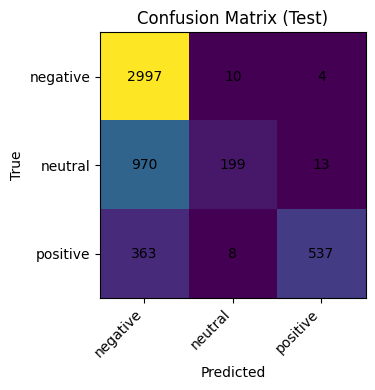

In [47]:

# ===========================
# Plot confusion matrix (matplotlib only, no seaborn)
# ===========================
labels = ['negative','neutral','positive']
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm)  # Do not specify a colormap explicitly
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.title('Confusion Matrix (Test)')
plt.tight_layout()
plt.show()


In [48]:
from joblib import dump
import os

# best_model remains the full fitted Pipeline

# =================================================================
# Option 1: Save the FULL pipeline (recommended for easy inference)
# UNCOMMENT THIS SECTION
# =================================================================
# This saves everything: cleaner, vectorizers, and classifier in one file
full_model_path = ARTIFACT_DIR / 'nb_bengali_sentiment_full_pipeline.joblib'
dump(best_model, full_model_path)
print('Saved full pipeline to:', full_model_path.resolve())


# =================================================================
# Option 2: Save components separately 
# KEEP THIS SECTION COMMENTED
# =================================================================
# # Extract components if needed (without reassigning best_model)
# clf = best_model.named_steps['clf']  # Trained MultinomialNB
# features = best_model.named_steps['features']  # Fitted FeatureUnion (vectorizers)

# # Save the classifier
# clf_path = ARTIFACT_DIR / 'nb_bengali_sentiment_clf.joblib'
# dump(clf, clf_path)
# print('Saved classifier to:', clf_path.resolve())

# # Save the features (vectorizers)
# features_path = ARTIFACT_DIR / 'nb_bengali_sentiment_features.joblib'
# dump(features, features_path)
# print('Saved features (vectorizers) to:', features_path.resolve())

# # Optionally, save the cleaner
# cleaner_path = ARTIFACT_DIR / 'nb_bengali_sentiment_cleaner.joblib'
# dump(best_model.named_steps['clean'], cleaner_path)
# print('Saved cleaner to:', cleaner_path.resolve())

Saved full pipeline to: C:\Users\DELL\Desktop\nlp_codes\artifacts\nb_bengali_sentiment_full_pipeline.joblib


In [49]:
# =================================================================
# Option 2: Save components separately (if you prefer modularity)
# UNCOMMENT THIS SECTION
# =================================================================
# Extract components
clf = best_model.named_steps['clf']
features = best_model.named_steps['features']

# Save the classifier
clf_path = ARTIFACT_DIR / 'nb_bengali_sentiment_clf.joblib'
dump(clf, clf_path)
print('Saved classifier to:', clf_path.resolve())

# Save the features (vectorizers)
features_path = ARTIFACT_DIR / 'nb_bengali_sentiment_features.joblib'
dump(features, features_path)
print('Saved features (vectorizers) to:', features_path.resolve())

# Save the cleaner
cleaner_path = ARTIFACT_DIR / 'nb_bengali_sentiment_cleaner.joblib'
dump(best_model.named_steps['clean'], cleaner_path)
print('Saved cleaner to:', cleaner_path.resolve())

Saved classifier to: C:\Users\DELL\Desktop\nlp_codes\artifacts\nb_bengali_sentiment_clf.joblib
Saved features (vectorizers) to: C:\Users\DELL\Desktop\nlp_codes\artifacts\nb_bengali_sentiment_features.joblib
Saved cleaner to: C:\Users\DELL\Desktop\nlp_codes\artifacts\nb_bengali_sentiment_cleaner.joblib


In [50]:
# predict.py

from joblib import load
from pathlib import Path
from typing import List
import numpy as np # Often needed, good practice to include

# --- Configuration ---

# Set the path to the directory containing your saved model artifacts.
# The 'r' before the string is important on Windows to handle backslashes correctly.
ARTIFACT_DIR = Path(r'./artifacts') 

# The name of the saved full pipeline file.
MODEL_FILENAME = 'nb_bengali_sentiment_full_pipeline.joblib'

# --- Load the Model ---

# Construct the full path to the model file.
model_path = ARTIFACT_DIR / MODEL_FILENAME

# Check if the model file exists before trying to load it.
if not model_path.exists():
    raise FileNotFoundError(f"Model file not found at: {model_path.resolve()}")

# Load the entire pipeline object from the file.
# This single object contains your cleaner, vectorizers, and classifier.
print(f"Loading model from: {model_path.resolve()}")
model_pipeline = load(model_path)
print("Model loaded successfully.")


# --- Prediction Function ---

def predict_sentiment(texts: List[str]) -> List[str]:
    """
    Takes a list of Bengali text strings and returns a list of predicted sentiments.
    
    Args:
        texts: A list of strings to analyze.
        
    Returns:
        A list of predicted sentiment labels ('positive', 'negative', 'neutral').
    """
    if not isinstance(texts, list):
        raise TypeError("Input must be a list of strings.")
    
    # The loaded pipeline handles all steps automatically: cleaning, vectorizing, and classifying.
    predictions = model_pipeline.predict(texts)
    
    return predictions.tolist()


# --- Example Usage ---

if __name__ == '__main__':
    # Here you can put new sentences to test the model.
    sample_texts = [
        'এই সেবাটি চমৎকার এবং খুবই সহায়ক।',       # "This service is excellent and very helpful." (positive)
        'আমি হতাশ, কিছুই ঠিকভাবে কাজ করছে না।',    # "I am disappointed, nothing is working correctly." (negative)
        'আগামীকাল মিটিং অনুষ্ঠিত হবে।',            # "The meeting will be held tomorrow." (neutral)
        'খাবারের মান খুবই বাজে ছিল',              # "The food quality was very bad" (negative)
    ]

    print("\n--- Making Predictions ---")
    # Call the prediction function with the sample texts.
    predicted_labels = predict_sentiment(sample_texts)

    # Print the results in a user-friendly way.
    for text, label in zip(sample_texts, predicted_labels):
        print(f"Text: '{text}'\n  -> Predicted Sentiment: {label}\n")

Loading model from: C:\Users\DELL\Desktop\nlp_codes\artifacts\nb_bengali_sentiment_full_pipeline.joblib
Model loaded successfully.

--- Making Predictions ---
Text: 'এই সেবাটি চমৎকার এবং খুবই সহায়ক।'
  -> Predicted Sentiment: positive

Text: 'আমি হতাশ, কিছুই ঠিকভাবে কাজ করছে না।'
  -> Predicted Sentiment: negative

Text: 'আগামীকাল মিটিং অনুষ্ঠিত হবে।'
  -> Predicted Sentiment: negative

Text: 'খাবারের মান খুবই বাজে ছিল'
  -> Predicted Sentiment: negative



In [51]:

# ===========================
# Quick inference
# ===========================
def predict(texts: List[str]) -> List[str]:
    return best_model.predict(texts).tolist()

samples = [
    'দারুণ উদ্যোগ',                # likely positive
    'এটা একদম বাজে',               # likely negative
    'এটা কেমন হবে বুঝতে পারছি না',# maybe neutral
    "তারা চায় জনগণ গরিব হোক, যেমন ডঃ ইউনুস দেশের গরিবের টাকা শুষে নিচ্ছে, এটা সাধারণ মানুষ বোঝে না, কিন্তু যারা কিছু লেখাপড়া করেছেন ওনারা হয়তো বা বুঝবেন"
]
print('Samples:', samples)
print('Pred:', predict(samples))


Samples: ['দারুণ উদ্যোগ', 'এটা একদম বাজে', 'এটা কেমন হবে বুঝতে পারছি না', 'তারা চায় জনগণ গরিব হোক, যেমন ডঃ ইউনুস দেশের গরিবের টাকা শুষে নিচ্ছে, এটা সাধারণ মানুষ বোঝে না, কিন্তু যারা কিছু লেখাপড়া করেছেন ওনারা হয়তো বা বুঝবেন']
Pred: ['positive', 'negative', 'negative', 'negative']


Graph saved to: roc_auc_curve_sentiment.png


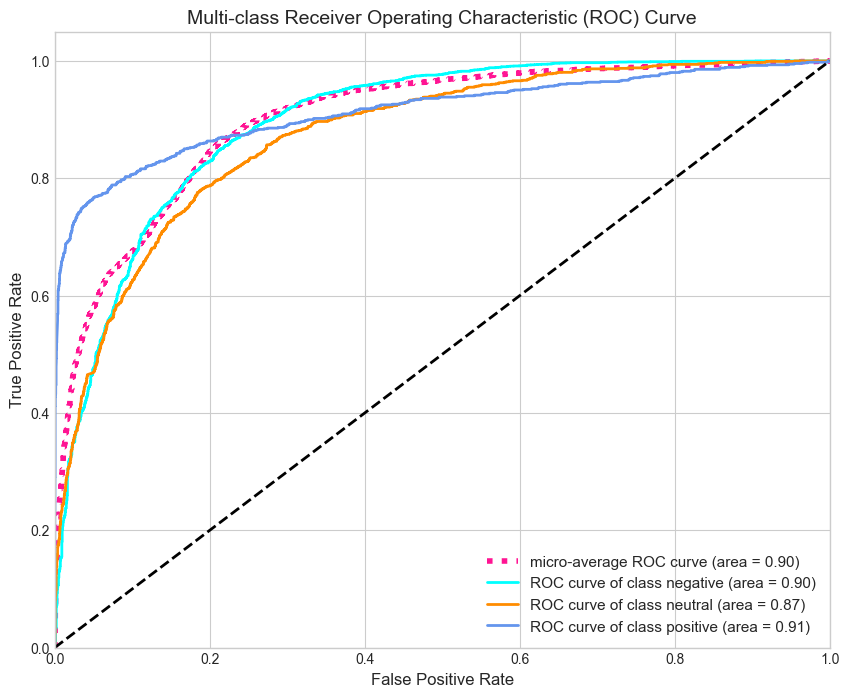

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# =======================================================
# Plotting the ROC AUC Curve for the Multiclass Model
# =======================================================

# Your trained model is `best_model`
# Your test data is `X_test` and `y_test`

# --- 1. Get the class labels ---
# Ensure the labels are sorted for consistent ordering
class_labels = sorted(df['sentiment'].unique().tolist()) # Or df['sentiment'].unique()
n_classes = len(class_labels)

# --- 2. Binarize the true labels (y_test) ---
# This converts the text labels (e.g., 'low', 'moderate') into a one-hot encoded format
y_test_binarized = label_binarize(y_test, classes=class_labels)

# --- 3. Get the prediction probabilities for the test set ---
# This gives the probability for each class for each sample in X_test
y_pred_proba = best_model.predict_proba(X_test)

# --- 4. Compute ROC curve and ROC area for each class ---
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 5. Compute micro-average ROC curve and ROC area ---
# This aggregates the predictions and true labels to compute a single curve
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# --- 6. Plot all ROC curves ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))

# Plot the micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:0.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# Plot the ROC curve for each class
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:0.2f})')

# Plot the diagonal "no-skill" line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# --- 7. Formatting the plot ---
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)


# =======================================================
# --- 8. SAVE THE FIGURE (ADD THIS SECTION) ---
# =======================================================
# Define the filename for the saved image. You can change this.
output_filename = 'roc_auc_curve_sentiment.png'

# Save the figure to a file. This MUST be before plt.show()
# dpi=300 makes it high resolution for reports or presentations.
# bbox_inches='tight' removes extra white space around the plot.
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

print(f"Graph saved to: {output_filename}")
# =======================================================


# Finally, display the plot in the notebook
plt.show()

Confusion matrix plot saved to: confusion_matrix_heatmap_senti.png


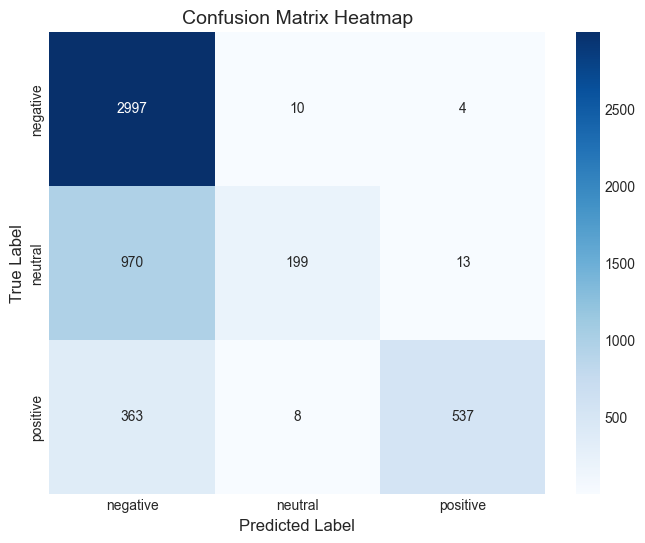

In [55]:

!pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Get the class labels from the trained model ---
# This is a robust way to get the labels in the correct order.
class_labels = best_model.classes_

# --- 2. Create the plot ---
# Set a good figure size for clarity
plt.figure(figsize=(8, 6))

# --- 3. Generate the heatmap ---
# annot=True: Writes the data value in each cell.
# fmt='d': Formats the numbers as integers.
# cmap='Blues': Uses the sequential blue color map, a very common and clear standard.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)

# --- 4. Add labels and a title for clarity ---
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix Heatmap', fontsize=14)

# Optional: Save the figure before showing it
plt.savefig('confusion_matrix_heatmap_eof.png', dpi=300, bbox_inches='tight')

# --- 5. SAVE THE FIGURE (ADD THIS PART) ---
# Define the filename for the saved image.
output_filename = 'confusion_matrix_heatmap_senti.png'


print(f"Confusion matrix plot saved to: {output_filename}")
# ---------------------------------------------

# Display the plot
plt.show()

In [56]:
!pip install pandas openpyxl
import pandas as pd
import numpy as np

def export_informative_features_to_excel(model, n_features=15, filename='informative_features_senti.xlsx'):
    """
    Extracts the N most informative features for each class and saves them to an Excel file.
    
    Args:
        model: A trained scikit-learn Pipeline.
        n_features: The number of top features to extract for each class.
        filename: The name of the output Excel file.
    """
    print("Extracting informative features...")

    # --- 1. Get components from the pipeline ---
    feature_union = model.named_steps['features']
    feature_names = feature_union.get_feature_names_out()
    
    classifier = model.named_steps['clf']
    class_labels = classifier.classes_
    
    # --- 2. Prepare a dictionary to hold the data for the Excel file ---
    # This will have columns like: 'features_low', 'scores_low', 'features_moderate', etc.
    data_for_excel = {}
    
    # --- 3. Loop through each class to get its top features and scores ---
    for class_label in class_labels:
        # Get the log probabilities for the current class
        log_probs = classifier.feature_log_prob_[class_label == class_labels][0]
        
        # Find the indices of the top N features
        top_indices = np.argsort(log_probs)[-n_features:]
        
        # Get the corresponding feature names and their scores
        top_features = feature_names[top_indices]
        top_scores = log_probs[top_indices]
        
        # Add the data to our dictionary, reversing the order to have the top feature first
        data_for_excel[f'features_{class_label}'] = top_features[::-1]
        data_for_excel[f'scores_{class_label}'] = top_scores[::-1]
        
    # --- 4. Create a pandas DataFrame and save it to Excel ---
    try:
        df_features = pd.DataFrame(data_for_excel)
        df_features.to_excel(filename, index=False, engine='openpyxl')
        
        # If you don't have openpyxl, you might need to install it:
        # !pip install openpyxl
        
        print(f"\nSuccessfully saved the data to '{filename}'")
        print("You can now open this file in Excel to create your charts.")
        
    except Exception as e:
        print(f"\nAn error occurred while saving to Excel: {e}")
        print("Please ensure you have pandas and openpyxl installed (`pip install pandas openpyxl`).")


# --- Call the function with your trained model ---
export_informative_features_to_excel(best_model, n_features=15)

Extracting informative features...

Successfully saved the data to 'informative_features_senti.xlsx'
You can now open this file in Excel to create your charts.
